In [93]:
import pandas as pd
import numpy as np

In [94]:
np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)
df=df.sample(40)

In [95]:
df

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1
29,1.425140,1.441152,0.182561,0
31,2.224431,0.230401,1.192120,0
4,0.322272,0.060343,-1.043450,1
32,-0.723253,1.461259,-0.085367,0
33,2.823378,-0.332863,2.637391,0


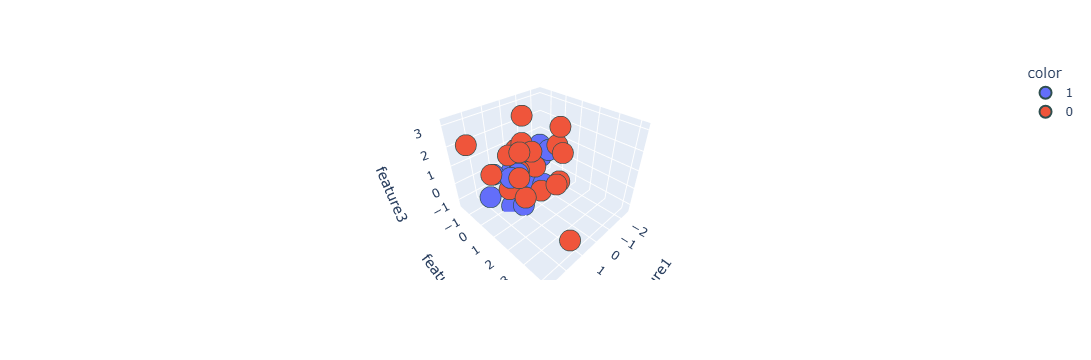

In [96]:
import plotly.express as px
fig=px.scatter_3d(df,x=df["feature1"],y=df["feature2"],z=df["feature3"],color=df["target"].astype("str"))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [97]:

#step 1
# now we will apply standard scaling
# mean centering
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
st.fit(df.iloc[:,[0,1,2]])
df.iloc[:,0:3]=st.transform(df.iloc[:,[0,1,2]])

In [98]:
#step 2
# covariance matrix
cov_matrix=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
cov_matrix

array([[1.02564103, 0.20478114, 0.080118  ],
       [0.20478114, 1.02564103, 0.19838882],
       [0.080118  , 0.19838882, 1.02564103]])

In [99]:
# step 3
# eigen value and eigen vector
eigen_values,eigen_vectors=np.linalg.eig(cov_matrix)

In [100]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [101]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

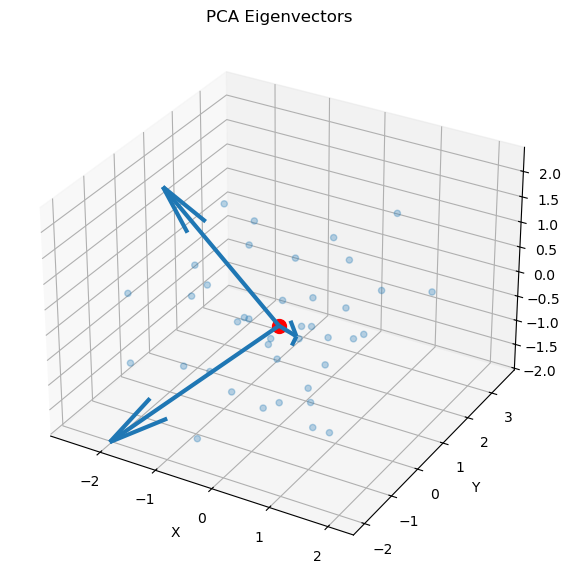

In [102]:
# Compute mean
mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()

# Center data (IMPORTANT)
X_centered = df[['feature1','feature2','feature3']] - [mean_x, mean_y, mean_z]

# Covariance matrix
cov_matrix = np.cov(X_centered.T)

# Eigen decomposition
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors (VERY IMPORTANT)
idx = eigen_values.argsort()[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# Plot
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Plot data
ax.scatter(df['feature1'],
           df['feature2'],
           df['feature3'],
           alpha=0.3)

# Plot mean point
ax.scatter(mean_x, mean_y, mean_z,
           color='red', s=100)

# Draw eigenvectors properly scaled
for i in range(len(eigen_values)):
    vector = eigen_vectors[:, i]
    length = np.sqrt(eigen_values[i]) * 3  # better scaling

    ax.quiver(mean_x, mean_y, mean_z,
              vector[0], vector[1], vector[2],
              length=length,
              normalize=True,
              linewidth=3)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("PCA Eigenvectors")
plt.show()


In [103]:
pc=eigen_vector[0:2,:]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [105]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head(10)

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1
5,-1.320157,-0.257002,0
6,-0.470834,-1.373121,0
7,-0.401542,1.203061,1
8,-0.433734,1.153326,0
9,0.227326,-2.669841,0


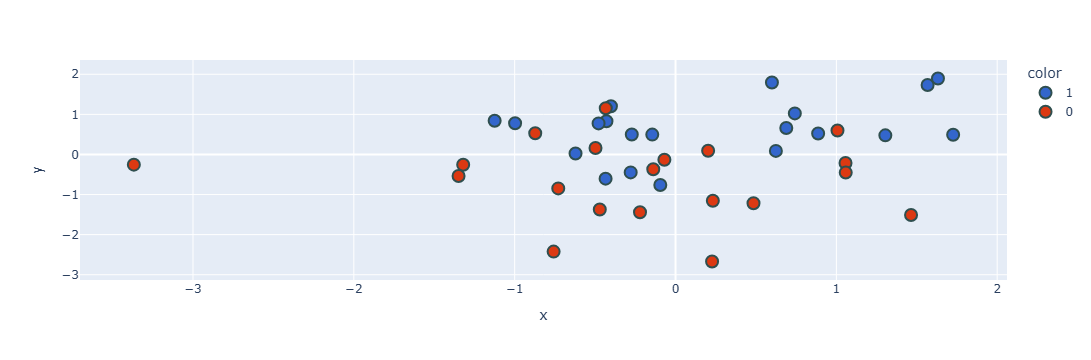

In [106]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()